<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 94 · Multiple Linear Regression</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Multiple Linear Regression</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Read partial slopes 'holding the others constant', compare models with adjusted R-squared, encode categories and interactions, and diagnose multicollinearity with the VIF, all library-first on real car data.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## Multiple regression: many predictors, one honest story
Library-first with `statsmodels`: we read partial slopes 'holding the others constant', draw a coefficient forest plot, watch adjusted R-squared punish a junk predictor, encode a category, test an interaction, and diagnose then cure multicollinearity with the VIF, all on real car data.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 1 &#183; STEPS 1&#8211;3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit the model and read the coefficients</div>
<div style="color:#4a5578;margin-top:6px">Explore, fit mpg on several predictors, and interpret each partial slope net of the others.</div>
</div>

In [2]:
try:
    cars = pd.read_excel('../../data/ch94_cars.xlsx', sheet_name='Cars')
except FileNotFoundError:
    cars = pd.read_excel(BASE + 'ch94_cars.xlsx', sheet_name='Cars')
print(cars.shape); cars.head(3)

(260, 6)


,car_id,origin,weight,horsepower,displacement,mpg
0,C100,Europe,2519,120,227,43.2
1,C101,Japan,4166,188,331,28.3
2,C102,Europe,3966,156,322,31.4


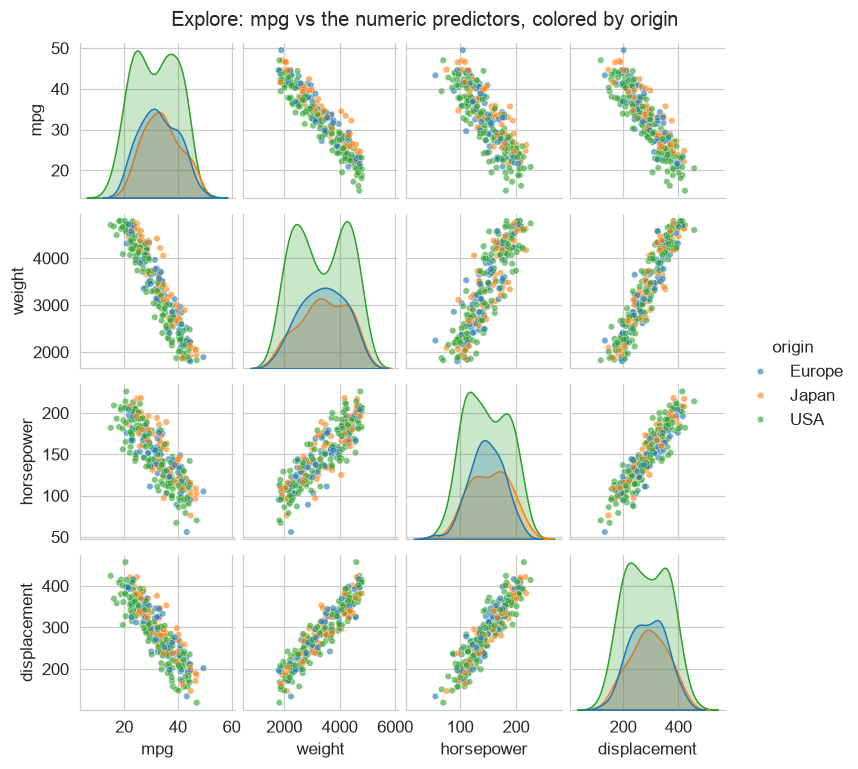

In [3]:
# EXPLORE FIRST: a pairwise look shows weight/hp/displacement move together (a hint of collinearity)
sns.pairplot(cars, vars=['mpg','weight','horsepower','displacement'], hue='origin',
             plot_kws=dict(s=18, alpha=0.6), height=1.7)
plt.suptitle('Explore: mpg vs the numeric predictors, colored by origin', y=1.02); plt.show()

In [4]:
full = ols('mpg ~ weight + horsepower + displacement + C(origin)', cars).fit()
print(full.summary().tables[1])
print(f'\nR2 = {full.rsquared:.3f}   adjusted R2 = {full.rsquared_adj:.3f}')

                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             60.6158      0.681     89.055      0.000      59.275      61.956
C(origin)[T.Japan]     1.4753      0.424      3.479      0.001       0.640       2.310
C(origin)[T.USA]      -1.6986      0.354     -4.793      0.000      -2.397      -1.001
weight                -0.0074      0.000    -15.424      0.000      -0.008      -0.006
horsepower            -0.0140      0.011     -1.308      0.192      -0.035       0.007
displacement          -0.0021      0.008     -0.274      0.784      -0.017       0.013

R2 = 0.903   adjusted R2 = 0.902


**Reading the coefficient table.** Each row is one predictor; the columns describe its effect:

- **coef** - the partial slope: the change in mpg per one-unit rise in that predictor, *holding the others constant*. weight = -0.0074 means each extra pound costs about 0.0074 mpg.
- **std err** - the standard error: how much the coefficient would wobble from sample to sample. Smaller means more precise.
- **t** - coef divided by std err: how many standard errors the estimate sits from zero.
- **P>|t|** - the p-value: the chance of a t this large if the true coefficient were zero. Below 0.05 we call the effect statistically significant. Here horsepower (0.19) and displacement (0.78) are not.
- **[0.025  0.975]** - the 95% confidence interval for the coefficient; if it straddles 0 the effect could be nothing (as it does for horsepower and displacement).

The puzzle: the explore plots showed all three predictors relate to mpg, yet two look insignificant here. That contradiction is the signature of **multicollinearity**, which we quantify with VIF in DEMO 5.

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 2 &#183; WHICH PREDICTORS MATTER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The coefficient forest plot</div>
<div style="color:#4a5578;margin-top:6px">Plot each standardized coefficient with its 95% interval; the ones whose whisker clears zero are the real effects.</div>
</div>

**Why standardize first?** The raw predictors live on very different scales: weight is in thousands of pounds, horsepower in the low hundreds, and the origin dummies are just 0 or 1. So a raw weight coefficient of -0.0074 (per pound) and an origin coefficient of +1.5 (per whole category) are not comparable. Rescaling each numeric predictor to standard-deviation units (subtract its mean, divide by its SD) puts them all on one ruler, so every coefficient now reads as the effect of a one-standard-deviation change. Only then does a forest plot fairly show which predictor moves mpg the most.

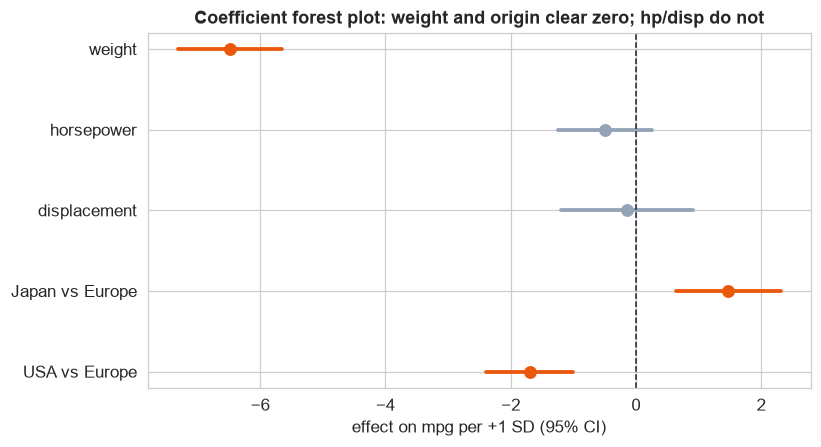

In [5]:
# Standardize numeric predictors so coefficients are comparable, then plot coef +/- CI
z = cars.copy()
for c in ['weight','horsepower','displacement']:
    z[c] = (cars[c]-cars[c].mean())/cars[c].std()
mz = ols('mpg ~ weight + horsepower + displacement + C(origin)', z).fit()
terms = ['weight','horsepower','displacement','C(origin)[T.Japan]','C(origin)[T.USA]']
labels = ['weight','horsepower','displacement','Japan vs Europe','USA vs Europe']
coef = mz.params[terms]; ci = mz.conf_int().loc[terms]
sig = (ci[0]*ci[1] > 0)   # CI does not cross zero
fig, ax = plt.subplots(figsize=(7.6,4.2)); yy = np.arange(len(terms))[::-1]
for i,t in enumerate(terms):
    col = ORG if sig[t] else GREY
    ax.plot([ci.loc[t,0], ci.loc[t,1]], [yy[i]]*2, color=col, lw=2.5, zorder=1)
    ax.scatter(coef[t], yy[i], color=col, s=55, zorder=2)
ax.axvline(0, color=INK, ls='--', lw=1)
ax.set_yticks(yy); ax.set_yticklabels(labels); ax.set_xlabel('effect on mpg per +1 SD (95% CI)')
ax.set_title('Coefficient forest plot: weight and origin clear zero; hp/disp do not'); plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; PARSIMONY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">R-squared always rises; adjusted R-squared does not</div>
<div style="color:#4a5578;margin-top:6px">Add a column of pure noise as a predictor. Plain R-squared ticks up; adjusted R-squared sees through it.</div>
</div>

In [6]:
rng = np.random.default_rng(0)
cars2 = cars.copy(); cars2['noise'] = rng.normal(size=len(cars))
base = ols('mpg ~ weight + C(origin)', cars).fit()
junk = ols('mpg ~ weight + C(origin) + noise', cars2).fit()
print(f'base   : R2={base.rsquared:.4f}  adjR2={base.rsquared_adj:.4f}')
print(f'+noise : R2={junk.rsquared:.4f}  adjR2={junk.rsquared_adj:.4f}')
print('R2 rose (it must), but adjusted R2 fell: the noise predictor did not earn its place.')

base   : R2=0.9020  adjR2=0.9009
+noise : R2=0.9022  adjR2=0.9007
R2 rose (it must), but adjusted R2 fell: the noise predictor did not earn its place.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 4 &#183; CATEGORIES &amp; INTERACTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Dummies give parallel lines; test before adding a slope change</div>
<div style="color:#4a5578;margin-top:6px">Interpret the origin dummies, then test whether each origin needs its own weight slope.</div>
</div>

In [7]:
red = ols('mpg ~ weight + C(origin)', cars).fit()
print('Origin offsets (vs Europe):')
print(f"  Japan: {red.params['C(origin)[T.Japan]']:+.2f} mpg   USA: {red.params['C(origin)[T.USA]']:+.2f} mpg")
inter = ols('mpg ~ weight * C(origin)', cars).fit()
ip = inter.pvalues.filter(like='weight:')
print('\nInteraction weight:C(origin) p-values:'); print(ip.round(3).to_string())
print('Both > 0.05 -> slopes do not significantly differ; parallel lines (no interaction) is the honest model.')

Origin offsets (vs Europe):
  Japan: +1.41 mpg   USA: -1.72 mpg

Interaction weight:C(origin) p-values:
weight:C(origin)[T.Japan]    0.196
weight:C(origin)[T.USA]      0.731
Both > 0.05 -> slopes do not significantly differ; parallel lines (no interaction) is the honest model.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 5 &#183; STEP 4 &amp; THE FIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Multicollinearity: measure with VIF, then prune</div>
<div style="color:#4a5578;margin-top:6px">Weight, horsepower and displacement all measure engine/body size. Quantify the overlap and cure it.</div>
</div>

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xv = sm.add_constant(cars[['weight','horsepower','displacement']].astype(float))
vifs = pd.Series({c: variance_inflation_factor(Xv.values, i) for i,c in enumerate(Xv.columns)})
print('VIFs:'); print(vifs.round(1).to_string())
reduced = ols('mpg ~ weight + C(origin)', cars).fit()
print(f'\nfull    adjR2 = {full.rsquared_adj:.3f}   weight coef = {full.params["weight"]:.5f}')
print(f'reduced adjR2 = {reduced.rsquared_adj:.3f}   weight coef = {reduced.params["weight"]:.5f}  95% CI {np.round(reduced.conf_int().loc["weight"].values,5)}')
print('Dropping the collinear predictors held the fit and stabilized the weight coefficient.')

VIFs:
const           18.9
weight           8.3
horsepower       6.6
displacement    13.3

full    adjR2 = 0.902   weight coef = -0.00741
reduced adjR2 = 0.901   weight coef = -0.00805  95% CI [-0.00838 -0.00772]
Dropping the collinear predictors held the fit and stabilized the weight coefficient.


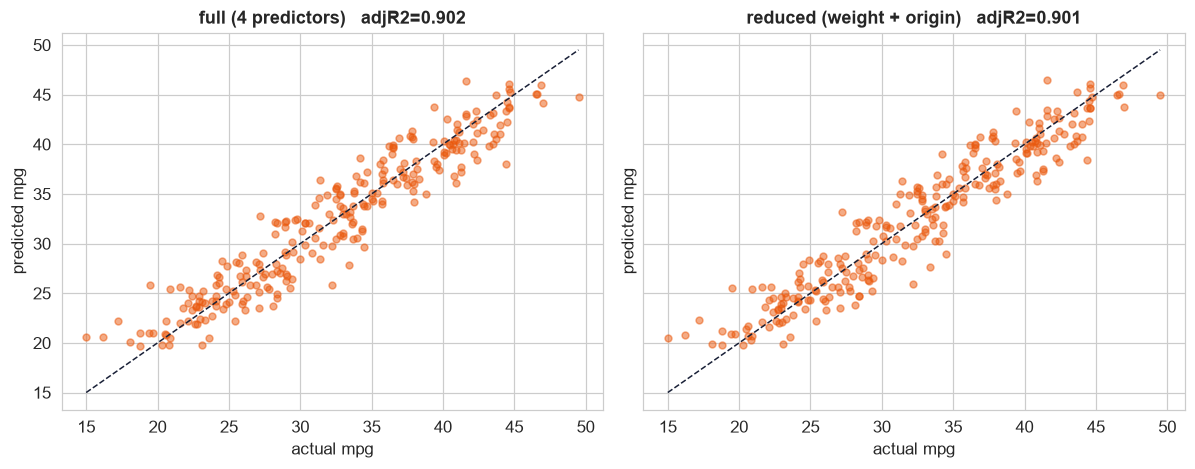

In [9]:
# Same predictive power: predicted vs actual for full and reduced models sit on the same line
fig, ax = plt.subplots(1, 2, figsize=(11,4.4), sharex=True, sharey=True)
for a, mdl, ttl in [(ax[0], full, 'full (4 predictors)'), (ax[1], reduced, 'reduced (weight + origin)')]:
    a.scatter(cars['mpg'], mdl.fittedvalues, s=20, color=ORG, alpha=0.5)
    lims = [cars['mpg'].min(), cars['mpg'].max()]
    a.plot(lims, lims, color=INK, ls='--', lw=1)
    a.set(title=f'{ttl}   adjR2={mdl.rsquared_adj:.3f}', xlabel='actual mpg', ylabel='predicted mpg')
plt.tight_layout(); plt.show()

## Putting it all together: what each step told us

We walked the full five-step workflow. Here is the whole story, and how each tool earned its place.

**Step 1, explore.** Scatterplots of mpg against weight, horsepower, and displacement all sloped down, so every predictor looked useful, but the predictors also moved together (correlations 0.87 to 0.94), the first warning sign.

**Step 2, fit.** We fit mpg ~ weight + horsepower + displacement + C(origin) so each coefficient is read *holding the others constant*.

**Step 3, evaluate with the coefficient forest plot.** The forest plot draws each standardized coefficient with its 95% interval. We used it to *select predictors*: a whisker that clears the zero line marks a real effect, one that straddles zero earns no conclusion. Weight and both origin effects cleared zero; horsepower and displacement did not, even though step 1 showed they matter. That mismatch is what flagged multicollinearity.

**R-squared vs adjusted R-squared.** R-squared is the share of mpg variation the model explains, but it can only rise when predictors are added, even useless ones. Adjusted R-squared penalizes each extra predictor, so it rises only if the predictor pulls its weight. We used it to compare models: adding a pure-noise column raised R-squared but lowered adjusted R-squared, and dropping displacement and horsepower held adjusted R-squared at 0.90, showing the leaner model is just as good.

**Categories and interaction.** Origin is categorical, so it entered as dummy variables with Europe as the reference; each origin gets the same weight slope but its own intercept (parallel lines). We then tested whether any origin needs its *own* weight slope by fitting weight * C(origin). The interaction p-values were all above 0.05, so the slopes do not significantly differ: origin did NOT need its own weight slope, and adding the interaction would only fit noise.

**VIF, the multicollinearity check.** The variance inflation factor measures how much a coefficient's variance is inflated by its correlation with the OTHER predictors (above 5 is a caution, above 10 is serious). We found VIFs of 13.3 (displacement), 8.3 (weight), and 6.6 (horsepower), confirming the three size measures are redundant. The fix was to drop the worst offenders and re-fit, after which the weight coefficient became stable with a tight interval. Key point: multicollinearity harms *interpretation*, not *prediction*, the full and reduced models predict mpg equally well (see the predicted-vs-actual plots above).

**Takeaway.** A model can fit beautifully and still mislead about *why*. The workflow, explore, fit, evaluate, check conditions with VIF, then interpret, is what turns a good fit into a trustworthy one.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>